In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [32]:
products = pd.read_csv(r"..\Blinkit_datasets\blinkit_products.csv")
orders_items = pd.read_csv(r"..\Blinkit_datasets\blinkit_order_items.csv")
inventory = pd.read_csv(r"..\Blinkit_datasets\blinkit_inventoryNew.csv")

In [33]:
orders_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price'], dtype='object')

In [34]:
products.columns

Index(['product_id', 'product_name', 'category', 'brand', 'price', 'mrp',
       'margin_percentage', 'shelf_life_days', 'min_stock_level',
       'max_stock_level'],
      dtype='object')

In [35]:
orders_items['item_revenue'] = orders_items['quantity'] * orders_items['unit_price']
ordered_products = pd.merge(products, orders_items, on = 'product_id', how = 'inner')

# Top product ids by revenue contribution

In [36]:
product_revenue = orders_items.groupby('product_id', as_index = False)['item_revenue'].sum().sort_values(by='item_revenue', ascending=False).head(30)

product_revenue['revenue_contribution'] = product_revenue['item_revenue'] / product_revenue['item_revenue'].sum() * 100
product_revenue.sort_values(by='revenue_contribution', ascending = False).head(20)

,product_id,item_revenue,revenue_contribution
15,51036,65212.70,5.028492
10,34186,56464.65,4.353937
233,880510,55182.94,4.255106
138,557908,51830.35,3.996591
65,264803,51790.96,3.993553
197,739534,48733.44,3.757791
6,18035,46509.12,3.586276
234,883013,45534.48,3.511122
84,349294,44868.00,3.459730
30,112390,43899.00,3.385012


- Out of 268 products, top 15 generate ~50% sales revenue

- A relatively small number of products contribute a significant portion of total revenue, with the top 15 products accounting for nearly half of overall sales. This highlights the importance of prioritizing these products in inventory planning, demand forecasting, and promotional campaigns.

# Top 20 products by sold quantities

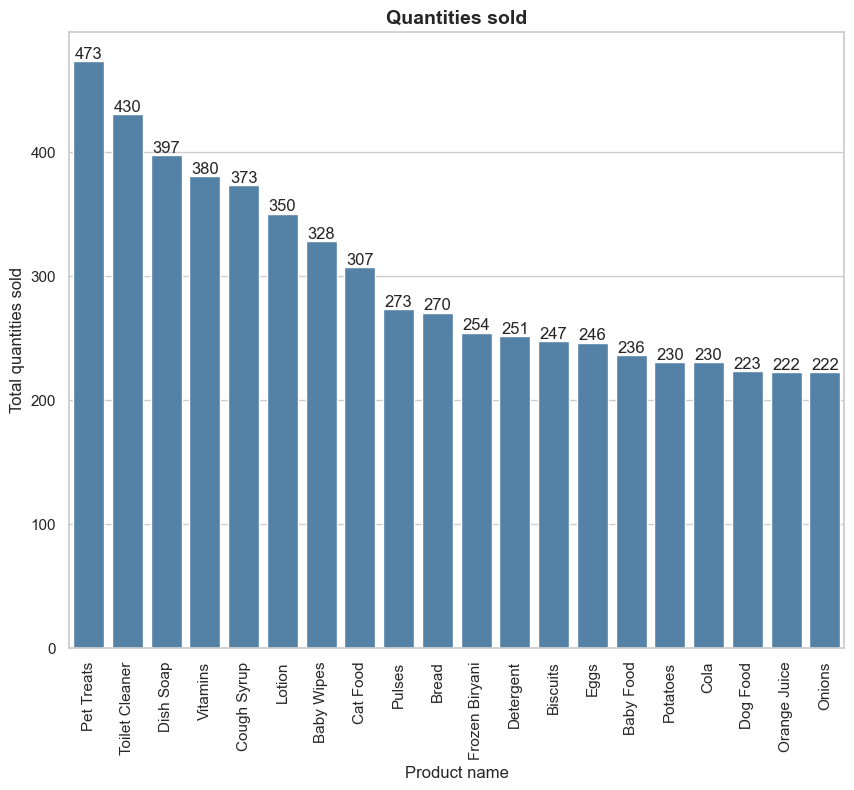

In [37]:
prod = ordered_products.groupby('product_name', as_index = False)['quantity'].sum().sort_values(by = 'quantity', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(data = prod, x = 'product_name', y = 'quantity', color = 'steelblue', ax = ax)

plt.title('Quantities sold', fontsize=14, fontweight='bold')
plt.xlabel('Product name')
plt.ylabel('Total quantities sold')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

- Household essentials, personal care products, pet supplies, and packaged food items account for the highest sales volumes. This indicates strong and recurring customer demand for frequently purchased everyday products, making them critical for inventory availability

# Top 20 products with highest revenue

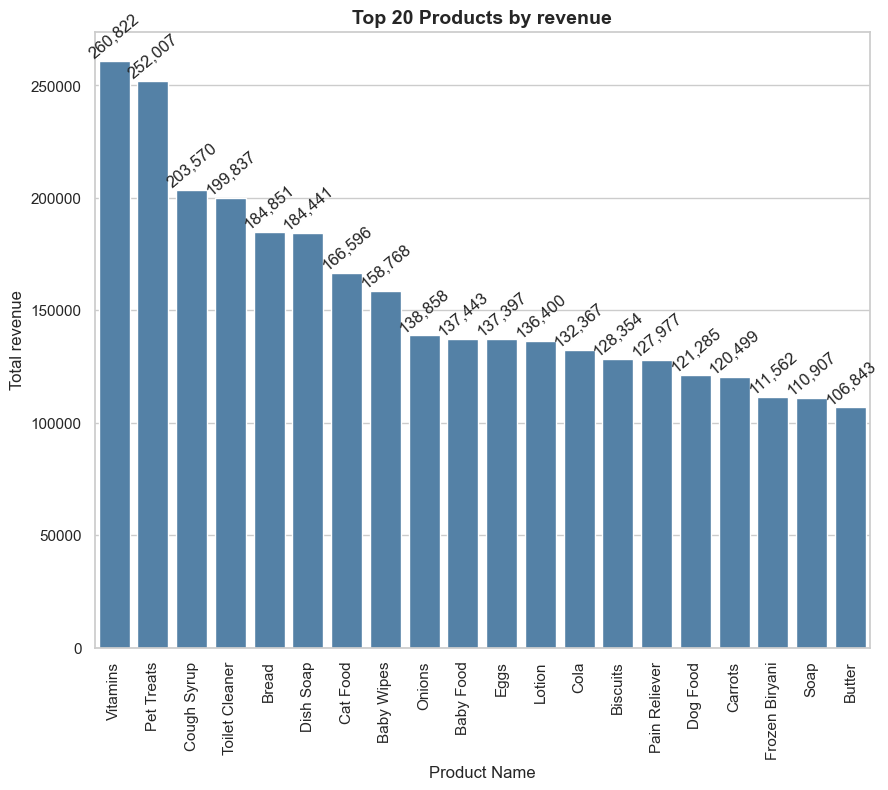

In [38]:
fig, ax = plt.subplots(figsize=(10,8))


prod = (ordered_products.groupby('product_name', as_index=False)['item_revenue'].sum().sort_values(by='item_revenue', ascending=False).head(20))

sns.barplot(data=prod,x='product_name',y='item_revenue',color='steelblue',ax=ax)

ax.set_title('Top 20 Products by revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Name')
ax.set_ylabel('Total revenue')
ax.tick_params(axis='x', rotation=90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', rotation=40)
plt.show()

- Products generating the highest revenue differ from those with the highest sales volume, indicating that premium-priced products contribute substantially to business revenue despite comparatively lower purchase frequency.

# Category-wise Quantity & Revenue

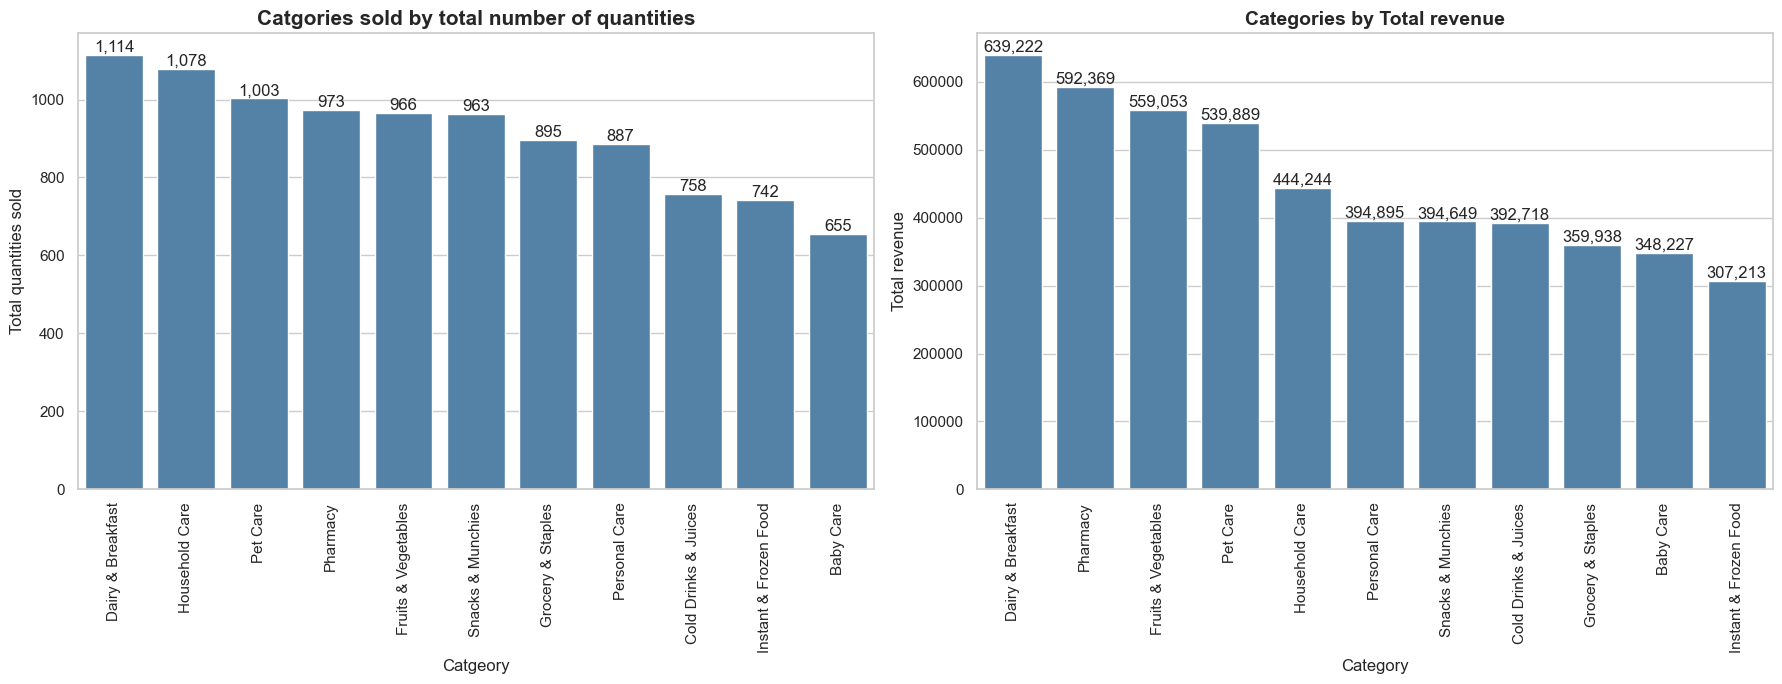

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

cat = ordered_products.groupby('category', as_index = False)['quantity'].sum().sort_values(by = 'quantity', ascending=False)

sns.barplot(data = cat, x = 'category', y = 'quantity', color = 'steelblue', ax = axes[0])

axes[0].set_title('Catgories sold by total number of quantities', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Catgeory')
axes[0].set_ylabel('Total quantities sold')
axes[0].tick_params(axis='x', rotation=90)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')


cat = (ordered_products.groupby('category', as_index=False)['item_revenue'].sum().sort_values(by='item_revenue', ascending=False))

sns.barplot(data=cat,x='category',y='item_revenue',color='steelblue',ax=axes[1])

axes[1].set_title('Categories by Total revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total revenue')
axes[1].tick_params(axis='x', rotation=90)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()

- Product categories contribute differently to business performance. While Fruits & Vegetables generate the highest sales volume, Dairy contributes the highest revenue, indicating that both customer demand and product pricing influence category performance

# Category wise margin percentage(discount)

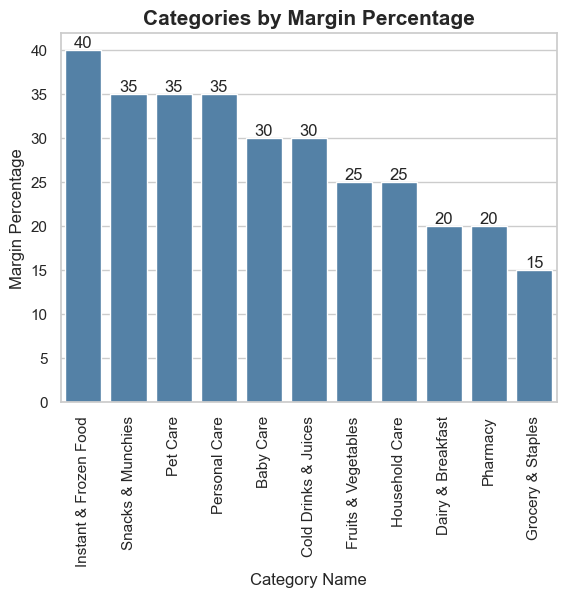

In [40]:
discount = products.groupby('category', as_index=False)['margin_percentage'].mean().sort_values(by='margin_percentage', ascending=False)

ax = sns.barplot(data = discount, x = 'category', y = 'margin_percentage', color = 'steelblue')

plt.title('Categories by Margin Percentage', fontsize=15, fontweight='bold')
plt.xlabel('Category Name')
plt.ylabel('Margin Percentage')
plt.xticks(rotation=90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.show()

- Discount percentages vary considerably across product categories. Categories such as Household Supplies and Instant Foods receive higher average discounts, suggesting a stronger reliance on promotional pricing, whereas Cleaning Supplies maintain comparatively lower discount levels

# Which price range products generates higher revenue

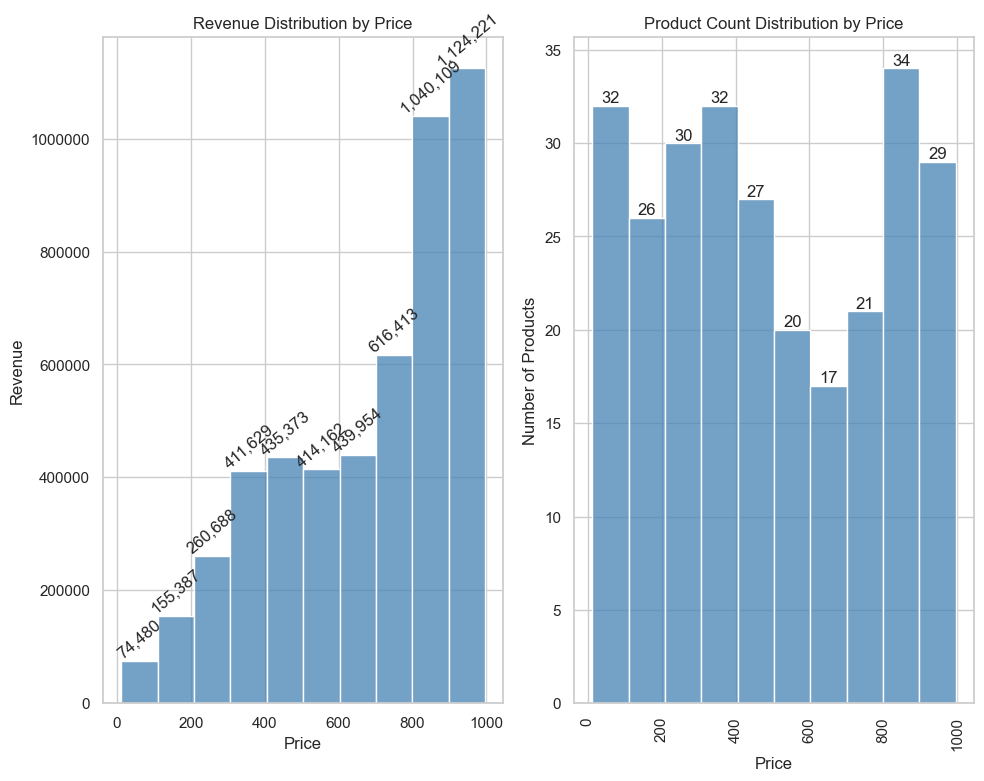

In [41]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize=(10,8))

sns.histplot(data=ordered_products,x='unit_price',weights='item_revenue',bins=10,color='steelblue',ax=axes[0])

axes[0].set_title('Revenue Distribution by Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Revenue')
axes[0].ticklabel_format(style='plain', axis='y')
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f'{height:,.0f}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom', rotation=40)


sns.histplot(data=products,x='price',bins=10,color='steelblue',ax=axes[1])

axes[1].set_title('Product Count Distribution by Price')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Number of Products')
axes[1].tick_params(axis='x', rotation=90)

for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom')

plt.tight_layout()
plt.show()

- Revenue increases noticeably as product price increases, indicating that higher-priced products contribute a substantial portion of total sales revenue despite representing a smaller share of transactions
- Products are distributed across multiple price ranges, with a relatively balanced assortment across low-, medium-, and high-priced items. This indicates a diversified product catalog catering to customers with varying spending preferences

# Revenue vs Margin percentage(Discount)

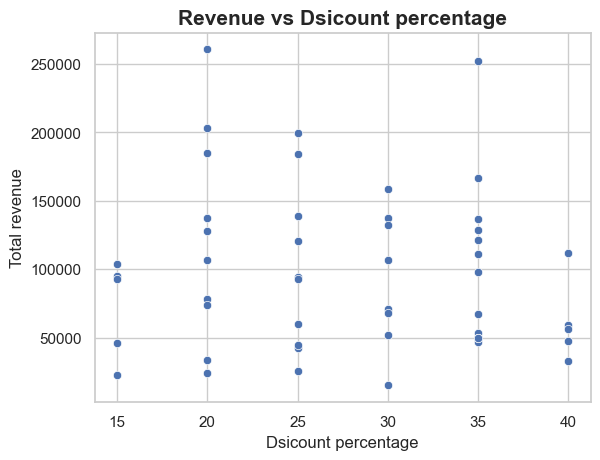

In [42]:
product_rev_discount = ordered_products.groupby('product_name', as_index=False).agg({'item_revenue':'sum','margin_percentage':'mean'}).reset_index()
sns.scatterplot(data=product_rev_discount,x='margin_percentage',y='item_revenue')

plt.title('Revenue vs Dsicount percentage', fontsize=15, fontweight='bold')
plt.xlabel('Dsicount percentage')
plt.ylabel('Total revenue')
plt.show()

- Products with similar discount percentages generate widely different revenue levels, indicating that discounting alone does not determine product performance. Other factors such as customer demand, product necessity, and pricing appear to have a greater influence on sales

# Revenue vs Quantity sold

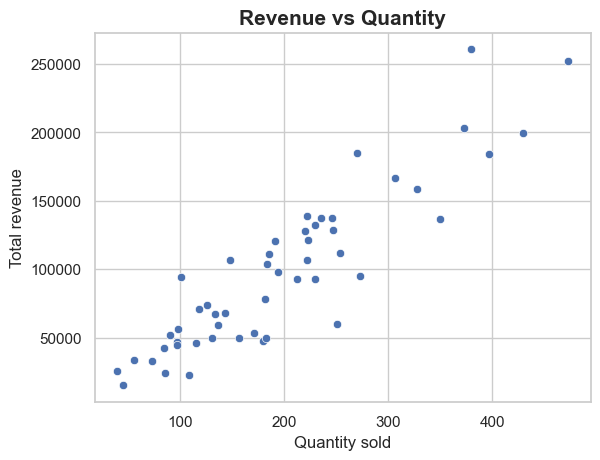

In [43]:
rev_qty = ordered_products.groupby('product_name').agg({'quantity':'sum','item_revenue':'sum'}).reset_index()
sns.scatterplot(data=rev_qty,x='quantity',y='item_revenue')
plt.title('Revenue vs Quantity', fontsize=15, fontweight='bold')
plt.xlabel('Quantity sold')
plt.ylabel('Total revenue')
plt.show()

- Revenue generally increases as product sales quantity increases, demonstrating a positive relationship between customer demand and revenue generation. However, several products achieve relatively high revenue with moderate sales quantities, reflecting the impact of premium pricing.

# Revenue share by category

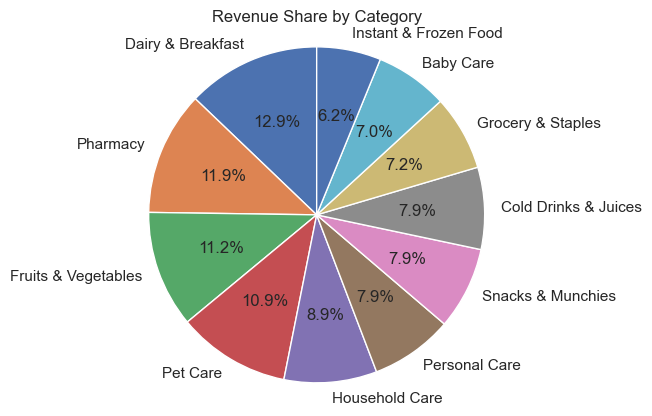

In [44]:
category_share = ordered_products.groupby('category', as_index=False).agg({'item_revenue':'sum'}).sort_values(by='item_revenue', ascending=False)
category_share.columns=['category', 'Revenue_share']
category_share['Revenue_share'] = (category_share['Revenue_share'] /category_share['Revenue_share'].sum()) * 100

plt.pie(category_share['Revenue_share'],labels=category_share['category'],autopct='%1.1f%%',startangle=90)

plt.title("Revenue Share by Category")
plt.axis('equal')  
plt.show()

- Revenue is distributed across multiple product categories rather than being concentrated within a single category. This balanced revenue mix reduces business dependence on individual product segments and contributes to overall business stability

# ABC Analysis

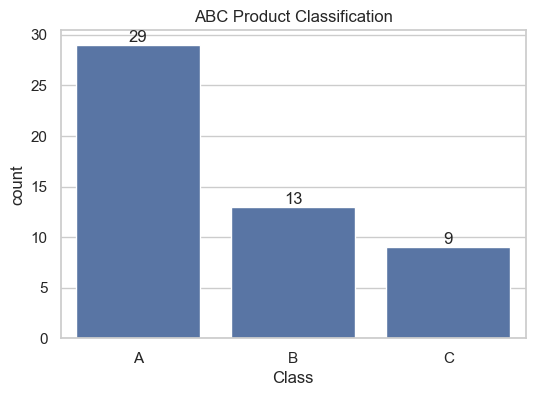

In [45]:
import numpy as np
abc = ordered_products.groupby('product_name', as_index=False)['item_revenue'].sum().sort_values(by='item_revenue', ascending=False).reset_index()
abc['item_revenue %'] = (abc['item_revenue'] /abc['item_revenue'].sum()) * 100

abc['Cumulative %'] = (abc['item_revenue %'].cumsum())

abc['Class'] = np.where(abc['Cumulative %'] <= 80,'A',np.where(abc['Cumulative %'] <=95,'B','C'))

class_labels = {
    'A': 'High Value Products (Core Revenue Drivers)',
    'B': 'Medium Value Products (Growth Potential)',
    'C': 'Low Value Products (Long Tail / Optimize or Remove)'
}

abc['Class_Label'] = abc['Class'].map(class_labels)

plt.figure(figsize=(6,4))

sns.countplot(data=abc, x='Class', order=['A','B','C'])

plt.title("ABC Product Classification")

for p in plt.gca().patches:
    plt.gca().annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

- Nearly half of all products fall into Class A, representing the products that contribute the majority of business revenue. Prioritizing inventory availability and replenishment for these products can significantly improve overall sales performance and customer satisfaction

# Quantity sold vs maximum stock

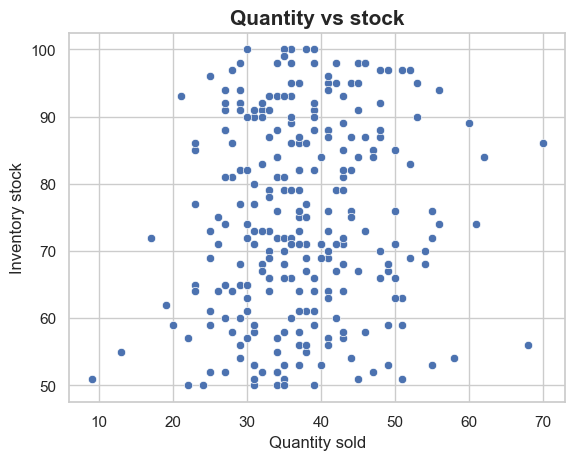

In [46]:
stock_qty = orders_items.groupby('product_id')['quantity'].sum()
stock_qty = stock_qty.to_frame()
stock_qty['stock_level'] = stock_qty.index.map(products.set_index('product_id')['max_stock_level'])

sns.scatterplot(data=stock_qty,x='quantity',y='stock_level')
plt.title('Quantity vs stock', fontsize=15, fontweight='bold')
plt.xlabel('Quantity sold')
plt.ylabel('Inventory stock')
plt.show()

- Inventory stock levels show only a weak relationship with product sales quantity. While several high-selling products maintain higher inventory levels, many products exhibit similar stock levels regardless of demand, suggesting opportunities to further optimize inventory allocation

In [47]:
inventory.columns

Index(['product_id', 'date', 'stock_received', 'damaged_stock'], dtype='object')

# Product stock vs product revenue

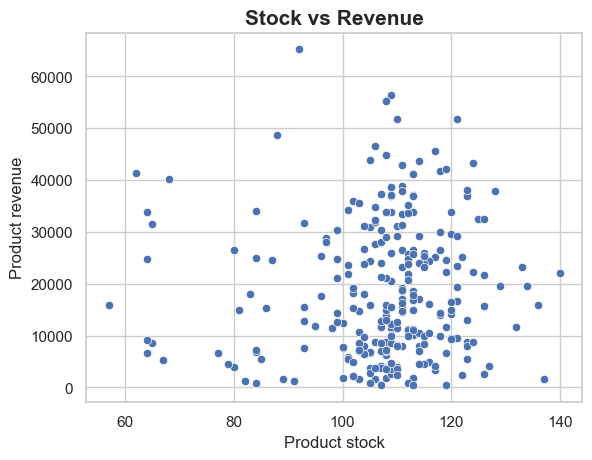

In [48]:
stock = inventory.groupby('product_id')['stock_received'].sum()
prod_revenue = orders_items.groupby('product_id')['item_revenue'].sum()

stock_df = stock.to_frame()
stock_df['prod_revenue'] = stock_df.index.map(prod_revenue)

sns.scatterplot(data=stock_df,x='stock_received',y='prod_revenue')
plt.title('Stock vs Revenue', fontsize=15, fontweight='bold')
plt.xlabel('Product stock')
plt.ylabel('Product revenue')
plt.show()

- Higher inventory levels do not consistently correspond to higher product revenue. This indicates that inventory allocation alone does not determine sales performance and highlights opportunities to better align stock levels with product revenue contribution

# Damage rate vs revenue impact

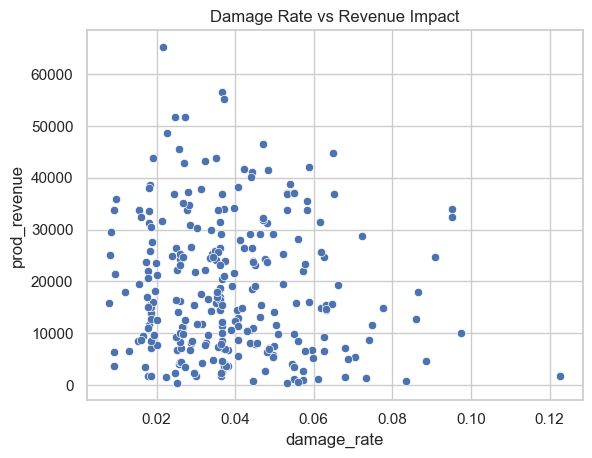

In [49]:
stock_total = inventory.groupby('product_id')['stock_received'].sum()
damage = inventory.groupby('product_id')['damaged_stock'].sum()

stock_df = pd.DataFrame({'stock_received': stock_total,'damaged_stock': damage})

stock_df['damage_rate'] = stock_df['damaged_stock'] / stock_df['stock_received']
stock_df['prod_revenue'] = stock_df.index.map(prod_revenue).fillna(0)

sns.scatterplot(data=stock_df,x='damage_rate',y='prod_revenue')

plt.title('Damage Rate vs Revenue Impact')
plt.show()

- Products with higher damage rates are distributed across both low- and high-revenue segments, indicating no strong relationship between inventory damage and product revenue. Monitoring high-revenue products with elevated damage rates could help reduce operational losses

# Monthly damage rate trend

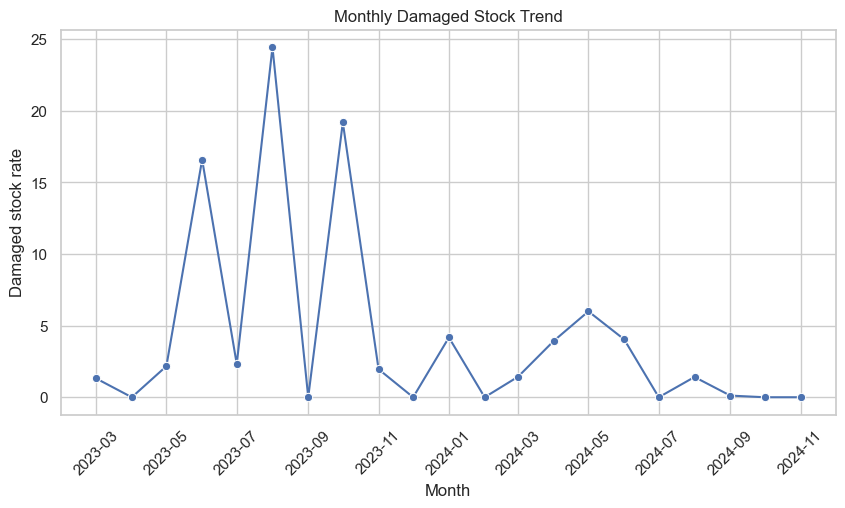

In [50]:
inventory['date'] = pd.to_datetime(inventory['date'], format='%b-%y')
inventory['month_period'] = inventory['date'].dt.to_period('M').dt.to_timestamp()

monthly_damage = inventory.groupby('month_period').agg({'damaged_stock': 'sum','stock_received': 'sum'}).reset_index()
monthly_damage['damage_rate'] = (monthly_damage['damaged_stock'] / monthly_damage['stock_received']) * 100

plt.figure(figsize=(10,5))

sns.lineplot(data = monthly_damage, x = 'month_period', y = 'damage_rate', marker = 'o')

plt.title('Monthly Damaged Stock Trend')
plt.xlabel('Month')
plt.ylabel('Damaged stock rate')
plt.xticks(rotation=45)
plt.show()

- Monthly damage rates fluctuate throughout the year, with noticeable spikes during specific months before stabilizing at relatively low levels. These spikes may indicate operational challenges such as storage issues, transportation losses, or seasonal handling variations that warrant further investigation

# Overall business insights

- Revenue is concentrated among a relatively small group of products, emphasizing the importance of effectively managing high-performing products through inventory planning and promotional strategies
- High sales volume does not necessarily translate into high revenue. While household essentials and frequently purchased products drive transaction volume, premium-priced products contribute significantly to overall revenue
- Revenue is well diversified across multiple product categories, reducing business dependence on any single category and creating a balanced product portfolio
- Discount percentage alone does not appear to be the primary driver of product revenue, suggesting that customer demand, product necessity, and pricing have a greater influence on purchasing behaviour
- Revenue increases with higher sales quantities; however, premium-priced products demonstrate that strong revenue can also be achieved with comparatively lower sales volumes
- Inventory levels are not consistently aligned with product demand or revenue, indicating opportunities to optimize stock allocation and improve inventory utilization
- Inventory damage remains relatively stable for most months, although periodic spikes suggest opportunities to strengthen warehouse operations and reduce inventory losses